In [1]:
import coralpsm
from coralpsm import ps_age_model

print(coralpsm.__version__)


0.1.0


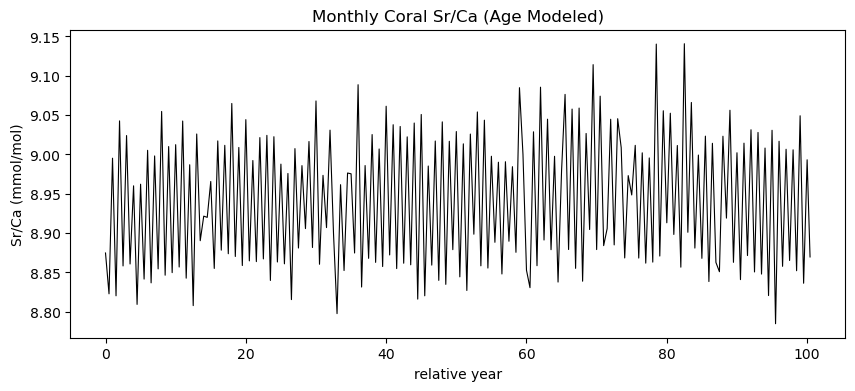

ValueError: 'x' has size 1190, but 'y1' has an unequal size of 1206

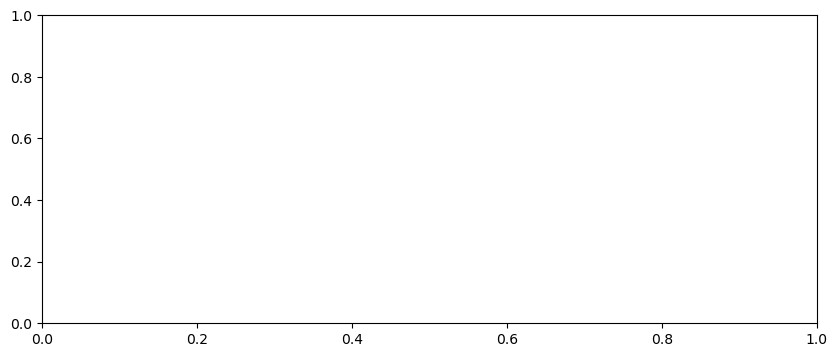

In [3]:
# demos/vanuatu_srca_demo.py

import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from coralpsm.ps_age_model import ps_age_model
from coralpsm.analytical_error import analytical_error

path ='Examples/ExampleData/Vanuatu_FossilCoral_11-TM-S5_SrCa.mat'
mat = scipy.io.loadmat(path)
srca = mat["SrCa"].squeeze()
depth = mat["depth"].squeeze()

# Invert so cool season = maxima
y = -srca

ts, extrema = ps_age_model(
    y,
    ppc_in=12,
    ppc_out=12,
    peak_loc=8,     # coolest month
    trough_loc=2,   # warmest month
)

# Undo inversion
ts[:,1] *= -1

plt.figure(figsize=(10,4))
plt.plot(ts[:,0], ts[:,1], "k-", lw=0.8)
plt.xlabel("relative year")
plt.ylabel("Sr/Ca (mmol/mol)")
plt.title("Monthly Coral Sr/Ca (Age Modeled)")
plt.show()

# Analytical error
ens = analytical_error(ts[:,1], sigma=0.008, n=10000)
plt.figure(figsize=(10,4))
plt.fill_between(
    depth,
    np.percentile(ens, 2.5, axis=1),
    np.percentile(ens,97.5, axis=1),
    color="royalblue",
    alpha=0.4
)
plt.plot(depth, ts[:,1], "k.")
plt.gca().invert_xaxis()
plt.show()
